### General Results of the optimisation

In [1]:
import pandas as pd
import numpy as np
import json
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker

# Get latest run
RESULTS_ROOT = Path("02-MODEL-RESULTS")
latest_run = sorted([d for d in RESULTS_ROOT.iterdir() if d.is_dir()])[-1]

# Load summary and settings
with open(latest_run / "results_summary.json", "r") as f:
    summary = json.load(f)
with open(latest_run / "settings_snapshot.json", "r") as f:
    settings = json.load(f)
active_parameters = settings.get("parameters", {})

# Load time series
df = pd.read_csv(latest_run / "timeseries_results.csv", parse_dates=['timestamp'])
df_soc = df.copy()
df_compare = pd.read_csv(latest_run / "baseline_vs_optimized.csv")
df_peak_metrics = pd.read_csv(latest_run / "peak_metrics.csv")
df_top_peaks = pd.read_csv(latest_run / "top_peak_intervals.csv", parse_dates=['timestamp'])
timestep_hours = pd.Series(pd.to_datetime(df["timestamp"])).diff().dropna().dt.total_seconds().median() / 3600 if "timestamp" in df.columns and len(df) > 1 else 0.25
monthly_summary_path = latest_run / "monthly_summary.csv"
if monthly_summary_path.exists():
    df_monthly = pd.read_csv(monthly_summary_path)
else:
    df_monthly = df.copy()
    df_monthly["month"] = df_monthly["timestamp"].dt.to_period("M").astype(str)
    price_per_kwh = 0.0
    if len(df_monthly) > 0 and df_monthly["grid_flow"].sum() > 0:
        price_per_kwh = summary.get("import_cost", 0.0) / (df_monthly["grid_flow"].sum() * 0.25)
    df_monthly["baseline_import_cost"] = df_monthly["baseline_grid_import"] * price_per_kwh * 0.25
    df_monthly["optimized_import_cost"] = df_monthly["grid_flow"] * price_per_kwh * 0.25
    df_monthly = df_monthly.groupby("month", as_index=False).agg(
        monthly_import_cost_before=("baseline_import_cost", "sum"),
        monthly_import_cost_after=("optimized_import_cost", "sum"),
        monthly_peak_before=("baseline_grid_import", "max"),
        monthly_peak_after=("grid_flow", "max"),
    )
    df_monthly["monthly_savings"] = df_monthly["monthly_import_cost_before"] - df_monthly["monthly_import_cost_after"]
    df_monthly["monthly_peak_reduction"] = df_monthly["monthly_peak_before"] - df_monthly["monthly_peak_after"]
weekly_summary_path = latest_run / "weekly_summary.csv"
if weekly_summary_path.exists():
    df_weekly = pd.read_csv(weekly_summary_path)
else:
    df_weekly = pd.DataFrame(
        columns=[
            "week_start",
            "weekly_import_energy_before_kwh",
            "weekly_import_energy_after_kwh",
            "weekly_energy_savings_kwh",
            "weekly_import_cost_before",
            "weekly_import_cost_after",
            "weekly_cost_savings",
            "weekly_peak_before",
            "weekly_peak_after",
            "weekly_peak_reduction",
        ]
    )
battery_utilization_path = latest_run / "battery_utilization_summary.csv"
if battery_utilization_path.exists():
    df_battery_util = pd.read_csv(battery_utilization_path)
elif {"battery_soc", "battery_charge_power", "battery_discharge_power"}.issubset(df.columns):
    installed_capacity = summary.get("battery_capacity_kwh", 0.0)
    avg_soc = df["battery_soc"].mean()
    min_soc = df["battery_soc"].min()
    max_soc = df["battery_soc"].max()
    discharged_energy = df["battery_discharge_power"].sum() * timestep_hours
    charged_energy = df["battery_charge_power"].sum() * timestep_hours
    equivalent_cycles = discharged_energy / installed_capacity if installed_capacity else float("nan")
    df_battery_util = pd.DataFrame([
        {"Metric": "Charged energy", "Value": charged_energy, "Unit": "kWh/year"},
        {"Metric": "Discharged energy", "Value": discharged_energy, "Unit": "kWh/year"},
        {"Metric": "Equivalent full cycles", "Value": equivalent_cycles, "Unit": "cycles/year"},
        {"Metric": "Average state of charge", "Value": avg_soc, "Unit": "kWh"},
        {"Metric": "Minimum state of charge", "Value": min_soc, "Unit": "kWh"},
        {"Metric": "Maximum state of charge", "Value": max_soc, "Unit": "kWh"},
        {"Metric": "Hours near empty (<=10%)", "Value": (df["battery_soc"] <= 0.10 * installed_capacity).sum() * timestep_hours, "Unit": "hours"},
        {"Metric": "Hours near full (>=90%)", "Value": (df["battery_soc"] >= 0.90 * installed_capacity).sum() * timestep_hours, "Unit": "hours"},
        {"Metric": "Maximum charge power used", "Value": df["battery_charge_power"].max(), "Unit": "kW"},
        {"Metric": "Maximum discharge power used", "Value": df["battery_discharge_power"].max(), "Unit": "kW"},
    ])
else:
    df_battery_util = pd.DataFrame(columns=["Metric", "Value", "Unit"])
battery_sensitivity_path = latest_run / "battery_size_sensitivity.csv"
if battery_sensitivity_path.exists():
    df_battery_sensitivity = pd.read_csv(battery_sensitivity_path)
else:
    df_battery_sensitivity = pd.DataFrame(columns=["battery_size_kwh", "objective_total_cost", "import_cost", "peak_demand_cost", "annualized_battery_cost", "annual_savings", "npv", "irr", "payback_years", "discounted_payback_years", "status"])
df_fin = pd.read_csv(latest_run / "financial_cashflows.csv")

def infer_timestep_hours(timestamp_series, default_hours=0.25):
    if timestamp_series is None or len(timestamp_series) < 2:
        return default_hours
    deltas = pd.Series(pd.to_datetime(timestamp_series)).diff().dropna()
    if deltas.empty:
        return default_hours
    step_hours = deltas.dt.total_seconds().median() / 3600
    return float(step_hours) if step_hours > 0 else default_hours

def format_duration(hours_value):
    if pd.isna(hours_value):
        return "-"
    hours_value = float(hours_value)
    abs_value = abs(hours_value)
    if abs_value < 1:
        return f"{hours_value * 60:,.0f} min"
    if abs_value < 48:
        return f"{hours_value:,.0f} h"
    if abs_value < 24 * 21:
        return f"{hours_value / 24:,.1f} d"
    return f"{hours_value / (24 * 7):,.1f} w"

def duration_tick_formatter(value, _):
    return format_duration(value)

timestep_hours = infer_timestep_hours(df["timestamp"]) if "timestamp" in df.columns else timestep_hours

for required_col in ["pv_flow", "grid_flow", "battery_charge_power", "battery_discharge_power", "total_load"]:
    if required_col not in df.columns:
        df[required_col] = 0.0
if "spill_flow" not in df.columns:
    df["spill_flow"] = 0.0
if "electricity_price" not in df.columns:
    df["electricity_price"] = 0.0

run_metadata = {
    "timestamp": settings.get("timestamp"),
    "timesteps_used": settings.get("timesteps_used"),
    "load_existing_input_dict": settings.get("load_existing_input_dict"),
    "max_timesteps": settings.get("max_timesteps"),
    "debug_infeasibility": settings.get("debug_infeasibility"),
}
settings_table_df = pd.DataFrame(
    [{"Section": "Run Metadata", "Name": key, "Value": value} for key, value in run_metadata.items()]
    + [{"Section": "Model Parameter", "Name": key, "Value": value} for key, value in active_parameters.items()]
)
metric_labels = {
    "runtime_seconds": "Runtime [s]",
    "objective_total_cost": "TAC / Objective Total Cost [CHF/year]",
    "opex": "OPEX [CHF/year]",
    "import_cost": "Import Cost [CHF/year]",
    "peak_demand_cost": "Peak Demand Cost [CHF/year]",
    "fixed_om_cost": "Fixed O&M Cost [CHF/year]",
    "variable_om_cost": "Variable O&M Cost [CHF/year]",
    "total_om_cost": "Total O&M Cost [CHF/year]",
    "annualized_battery_cost": "Annualized Battery Cost [CHF/year]",
    "battery_capacity_kwh": "Battery Capacity [kWh]",
    "battery_power_capacity_kw": "Battery Power Capacity [kW]",
    "yearly_peak": "Yearly Peak Grid Import [kW]",
    "sum_monthly_peaks": "Sum Monthly Peaks [kW]",
    "monthly_peaks": "Monthly Peaks [kW]",
    "curtailed_energy_kwh": "Curtailed Energy [kWh/year]",
    "discharged_energy_kwh": "Battery Discharged Energy [kWh/year]",
    "equivalent_full_cycles": "Equivalent Full Cycles [cycles/year]",
    "no_battery_import_cost": "No-Battery Import Cost [CHF/year]",
    "no_battery_peak_demand_cost": "No-Battery Peak Demand Cost [CHF/year]",
    "no_battery_total_cost": "No-Battery Total Cost [CHF/year]",
    "annual_savings": "Annual Savings [CHF/year]",
    "annual_total_cost_reduction": "Annual Total Cost Reduction [CHF/year]",
    "investment_cost": "Initial Investment Cost [CHF]",
    "energy_investment_cost": "Energy CAPEX [CHF]",
    "power_investment_cost": "Power CAPEX [CHF]",
    "replacement_cost": "Battery Replacement Cost [CHF]",
    "replacement_year": "Battery Replacement Year",
    "replacement_basis": "Replacement Basis",
    "npv": "NPV [CHF]",
    "irr": "IRR [-]",
    "payback_years": "Payback [years]",
    "discounted_payback_years": "Discounted Payback [years]",
}

preferred_metric_order = [
    "runtime_seconds",
    "objective_total_cost",
    "opex",
    "import_cost",
    "peak_demand_cost",
    "fixed_om_cost",
    "variable_om_cost",
    "total_om_cost",
    "annualized_battery_cost",
    "battery_capacity_kwh",
    "battery_power_capacity_kw",
    "yearly_peak",
    "sum_monthly_peaks",
    "monthly_peaks",
    "curtailed_energy_kwh",
    "discharged_energy_kwh",
    "equivalent_full_cycles",
    "no_battery_import_cost",
    "no_battery_peak_demand_cost",
    "no_battery_total_cost",
    "annual_savings",
    "annual_total_cost_reduction",
    "investment_cost",
    "energy_investment_cost",
    "power_investment_cost",
    "replacement_cost",
    "replacement_year",
    "replacement_basis",
    "npv",
    "irr",
    "payback_years",
    "discounted_payback_years",
]

summary_rows = []
for key in preferred_metric_order:
    if key in summary:
        value = summary[key]
        summary_rows.append(
            {
                "Metric": metric_labels.get(key, key),
                "Value": json.dumps(value) if isinstance(value, (dict, list)) else value,
            }
        )

for key, value in summary.items():
    if key not in preferred_metric_order:
        summary_rows.append(
            {
                "Metric": metric_labels.get(key, key),
                "Value": json.dumps(value) if isinstance(value, (dict, list)) else value,
            }
        )

detailed_summary_df = pd.DataFrame(summary_rows)

dispatch_df = df.copy()
dispatch_df["week_start"] = dispatch_df["timestamp"].dt.to_period("W").apply(lambda p: p.start_time)
weekly_summary = dispatch_df.groupby("week_start", as_index=False).agg(
    total_load=("total_load", "sum"),
    total_pv=("pv_flow", "sum"),
    total_grid_import=("grid_flow", "sum"),
    total_battery_charge=("battery_charge_power", "sum"),
    total_battery_discharge=("battery_discharge_power", "sum"),
    total_curtailment=("spill_flow", "sum"),
    avg_price=("electricity_price", "mean"),
    peak_load=("total_load", "max"),
)
weekly_summary["month"] = weekly_summary["week_start"].dt.month

def _pick_week(label, candidate_df, sort_columns):
    if candidate_df.empty:
        return None
    ordered = candidate_df.sort_values(sort_columns, ascending=[False] * len(sort_columns)).iloc[0]
    return {"label": label, "week_start": ordered["week_start"]}

week_candidates = [
    _pick_week("Winter Week", weekly_summary[weekly_summary["month"].isin([12, 1, 2])], ["total_load", "peak_load"]),
    _pick_week("Summer Week", weekly_summary[weekly_summary["month"].isin([6, 7, 8])], ["total_pv", "total_load"]),
    _pick_week("Highest-Load Week", weekly_summary, ["total_load", "peak_load"]),
    _pick_week("Highest-Price Week", weekly_summary, ["avg_price", "total_grid_import"]),
    _pick_week("Highest-Curtailment Week", weekly_summary, ["total_curtailment", "total_pv"]),
]
selected_dispatch_weeks = []
seen_week_starts = set()
for candidate in week_candidates:
    if candidate is None:
        continue
    week_start = candidate["week_start"]
    if week_start in seen_week_starts:
        continue
    seen_week_starts.add(week_start)
    selected_dispatch_weeks.append(candidate)
dispatch_week_table = pd.DataFrame(selected_dispatch_weeks)

print(f"Loaded results from: {latest_run.name}")

Loaded results from: 20260504_154821_lp_35137steps


In [2]:
from IPython.display import display, Markdown

def format_value(v):
    if isinstance(v, bool):
        return "Yes" if v else "No"
    if pd.isna(v):
        return "-"
    if isinstance(v, (int, float)):
        return f"{v:,.2f}"
    return v

display(Markdown("## Baseline vs Optimized Comparison"))
display(df_compare.style.format({
    "Baseline": format_value,
    "Optimized": format_value,
    "Optimized - Baseline": format_value,
}))


supplementary_kpis = [
    ("Battery energy size [kWh]", "battery_capacity_kwh"),
    ("Battery power rating [kW]", "battery_power_capacity_kw"),
    ("Annual Savings", "annual_savings"),
    ("Equivalent Full Cycles", "equivalent_full_cycles"),
    ("Replacement Basis", "replacement_basis"),
    ("Energy CAPEX [CHF]", "energy_investment_cost"),
    ("Power CAPEX [CHF]", "power_investment_cost"),
    ("Curtailed Energy (kWh)", "curtailed_energy_kwh"),
    ("Annual Peak", "yearly_peak"),
    ("Replacement Cost", "replacement_cost"),
    ("Replacement Year", "replacement_year"),
    ("IRR", "irr"),
]
kpi_df = pd.DataFrame([
    {"Metric": label, "Value": summary.get(key)}
    for label, key in supplementary_kpis
])

display(Markdown("## Supplementary KPIs"))
display(kpi_df.style.format({"Value": format_value}))

display(Markdown("## Run and Model Settings"))
display(settings_table_df.style.format({"Value": format_value}))

## Baseline vs Optimized Comparison

,Metric,Baseline,Optimized,Optimized - Baseline,Unit
0,Battery size,0.00,499.08,499.08,kWh
1,Battery power rating,0.00,249.54,249.54,kW
2,Annual import cost,-,-,-,CHF/year
3,Total annual cost,-,"40,039.28",-,CHF/year
4,Annual peak-demand cost,"33,490.57","28,699.39","-4,791.18",CHF/year
5,Annual import cost savings,0.00,-,-,CHF/year
6,Annual total cost reduction,0.00,-,-,CHF/year
7,CAPEX,0.00,"154,715.22","154,715.22",CHF
8,CAPEX energy component,0.00,"124,770.34","124,770.34",CHF
9,CAPEX power component,0.00,"29,944.88","29,944.88",CHF


## Supplementary KPIs

,Metric,Value
0,Battery energy size [kWh],499.08
1,Battery power rating [kW],249.54
2,Annual Savings,-
3,Equivalent Full Cycles,264.22
4,Replacement Basis,calendar_life
5,Energy CAPEX [CHF],"124,770.34"
6,Power CAPEX [CHF],"29,944.88"
7,Curtailed Energy (kWh),"278,249.68"
8,Annual Peak,"1,494.76"
9,Replacement Cost,0.00


## Run and Model Settings

,Section,Name,Value
0,Run Metadata,timestamp,2026-05-04T15:49:25
1,Run Metadata,timesteps_used,"35,137.00"
2,Run Metadata,load_existing_input_dict,No
3,Run Metadata,max_timesteps,-
4,Run Metadata,debug_infeasibility,No
5,Model Parameter,PV_max_capacity,"10,000.00"
6,Model Parameter,Battery_max_inflow,"1,000.00"
7,Model Parameter,Battery_max_outflow,"1,000.00"
8,Model Parameter,Battery_max_capacity,"100,000.00"
9,Model Parameter,Battery_eta_charge,0.90


In [3]:
display(Markdown("## Peak Import Before vs After Battery"))
display(df_peak_metrics.style.format({
    "Before battery": format_value,
    "After battery": format_value,
    "Reduction": format_value,
    "Reduction %": format_value,
}))

display(Markdown("### Top 10 Peak Intervals Reduced"))
display(df_top_peaks.head(10).style.format({
    "baseline_grid_import": format_value,
    "optimized_grid_import": format_value,
    "peak_reduction": format_value,
}))

## Peak Import Before vs After Battery

,Metric,Before battery,After battery,Reduction,Reduction %,Unit
0,Maximum grid import,"1,744.30","1,494.76",249.54,14.31,kW
1,95th percentile grid import,"1,002.14","1,002.22",-0.08,-0.01,kW


### Top 10 Peak Intervals Reduced

,timestamp,baseline_grid_import,optimized_grid_import,peak_reduction
0,2024-01-01 00:15:00,907.33,657.79,249.54
1,2024-11-06 06:15:00,"1,744.30","1,494.76",249.54
2,2024-01-01 00:00:00,494.92,245.38,249.54
3,2024-11-06 06:00:00,"1,740.96","1,494.76",246.20
4,2024-12-12 05:30:00,"1,731.52","1,494.76",236.76
5,2024-12-13 05:45:00,"1,727.00","1,494.76",232.24
6,2024-12-12 05:45:00,"1,725.65","1,494.76",230.89
7,2024-12-17 05:30:00,"1,725.42","1,494.76",230.66
8,2024-12-31 05:45:00,"1,724.78","1,494.76",230.02
9,2024-12-31 06:00:00,"1,723.76","1,494.76",229.00


## Grid Import Duration Curve

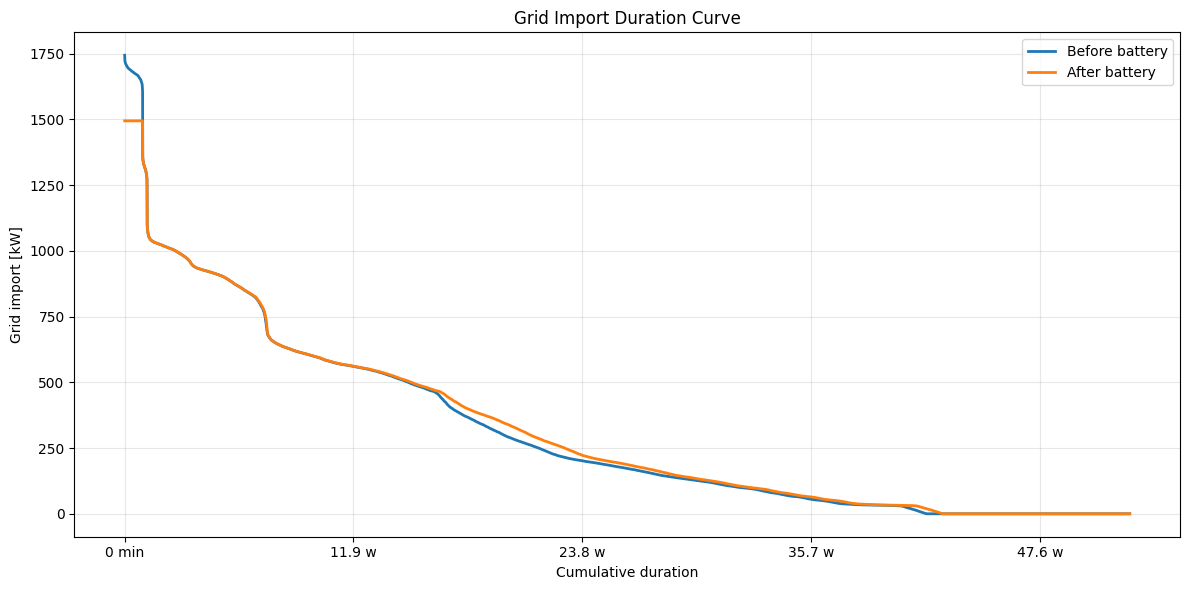

In [4]:
display(Markdown("## Grid Import Duration Curve"))

baseline_duration = df["baseline_grid_import"].sort_values(ascending=False).reset_index(drop=True)
optimized_duration = df["grid_flow"].sort_values(ascending=False).reset_index(drop=True)
duration_axis_hours = pd.Series(np.arange(1, len(baseline_duration) + 1) * timestep_hours)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(duration_axis_hours, baseline_duration, label="Before battery", linewidth=2)
ax.plot(duration_axis_hours, optimized_duration, label="After battery", linewidth=2)
ax.set_xlabel("Cumulative duration")
ax.set_ylabel("Grid import [kW]")
ax.set_title("Grid Import Duration Curve")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(duration_tick_formatter))
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

In [5]:
display(Markdown("## Monthly Savings and Peak Reduction"))
display(df_monthly.style.format({
    "monthly_import_cost_before": format_value,
    "monthly_import_cost_after": format_value,
    "monthly_savings": format_value,
    "monthly_peak_before": format_value,
    "monthly_peak_after": format_value,
    "monthly_peak_reduction": format_value,
}))

display(Markdown("## Weekly Savings and Peak Reduction"))
if df_weekly.empty:
    display(Markdown("_Run the model again to generate `weekly_summary.csv` for this section._"))
else:
    display(df_weekly.style.format({
        "weekly_import_energy_before_kwh": format_value,
        "weekly_import_energy_after_kwh": format_value,
        "weekly_energy_savings_kwh": format_value,
        "weekly_import_cost_before": format_value,
        "weekly_import_cost_after": format_value,
        "weekly_cost_savings": format_value,
        "weekly_peak_before": format_value,
        "weekly_peak_after": format_value,
        "weekly_peak_reduction": format_value,
    }))

## Monthly Savings and Peak Reduction

,month,monthly_import_cost_before,monthly_import_cost_after,monthly_savings,monthly_peak_before,monthly_peak_after,monthly_peak_reduction
0,2024-01,0.00,0.00,0.00,"1,704.81","1,494.76",210.05
1,2024-02,0.00,0.00,0.00,"1,710.51","1,494.76",215.75
2,2024-03,0.00,0.00,0.00,"1,699.59","1,494.76",204.83
3,2024-04,0.00,0.00,0.00,"1,105.51","1,105.51",0.00
4,2024-05,0.00,0.00,0.00,"1,081.39","1,081.39",0.00
5,2024-06,0.00,0.00,0.00,"1,033.82","1,033.82",0.00
6,2024-07,0.00,0.00,0.00,"1,048.24","1,048.24",0.00
7,2024-08,0.00,0.00,0.00,"1,042.85","1,042.85",0.00
8,2024-09,0.00,0.00,0.00,"1,062.53","1,062.53",0.00
9,2024-10,0.00,0.00,0.00,"1,719.56","1,494.76",224.80


## Weekly Savings and Peak Reduction

,week_start,weekly_import_energy_before_kwh,weekly_import_energy_after_kwh,weekly_energy_savings_kwh,weekly_import_cost_before,weekly_import_cost_after,weekly_cost_savings,weekly_peak_before,weekly_peak_after,weekly_peak_reduction
0,2023-12-26,"10,791.66","10,675.37",116.29,0.00,0.00,0.00,"1,643.35","1,494.76",148.59
1,2024-01-02,"64,542.13","64,732.45",-190.32,0.00,0.00,0.00,"1,704.81","1,494.76",210.05
2,2024-01-09,"66,260.97","66,449.82",-188.85,0.00,0.00,0.00,"1,693.19","1,494.76",198.43
3,2024-01-16,"64,812.60","65,383.92",-571.31,0.00,0.00,0.00,"1,698.66","1,494.76",203.90
4,2024-01-23,"61,944.84","62,675.58",-730.74,0.00,0.00,0.00,"1,694.16","1,494.76",199.40
5,2024-01-30,"62,143.07","63,041.24",-898.17,0.00,0.00,0.00,"1,706.95","1,494.76",212.19
6,2024-02-06,"60,018.89","60,926.79",-907.90,0.00,0.00,0.00,"1,705.82","1,494.76",211.06
7,2024-02-13,"58,045.04","58,926.40",-881.35,0.00,0.00,0.00,"1,688.77","1,494.76",194.01
8,2024-02-20,"58,391.47","59,554.74","-1,163.26",0.00,0.00,0.00,"1,689.32","1,494.76",194.56
9,2024-02-27,"57,438.82","58,336.76",-897.94,0.00,0.00,0.00,"1,710.51","1,494.76",215.75


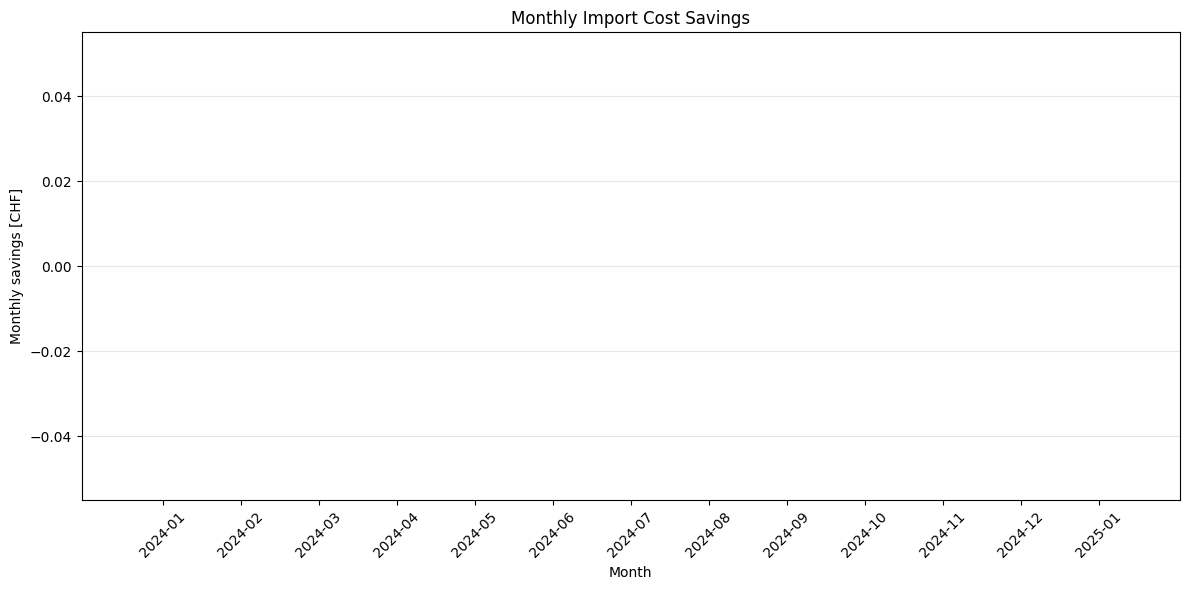

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(df_monthly["month"], df_monthly["monthly_savings"], color="steelblue")
ax.set_xlabel("Month")
ax.set_ylabel("Monthly savings [CHF]")
ax.set_title("Monthly Import Cost Savings")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:
display(Markdown("## Battery Utilization Metrics"))
display(df_battery_util.style.format({"Value": format_value}))

## Battery Utilization Metrics

,Metric,Value,Unit
0,Charged energy,"154,228.02",kWh/year
1,Discharged energy,"131,864.95",kWh/year
2,Equivalent full cycles,264.22,cycles/year
3,Average state of charge,103.82,kWh
4,Minimum state of charge,99.82,kWh
5,Maximum state of charge,348.05,kWh
6,Hours near empty (<=10%),0.00,hours
7,Hours near full (>=90%),0.00,hours
8,Maximum charge power used,249.54,kW
9,Maximum discharge power used,249.54,kW


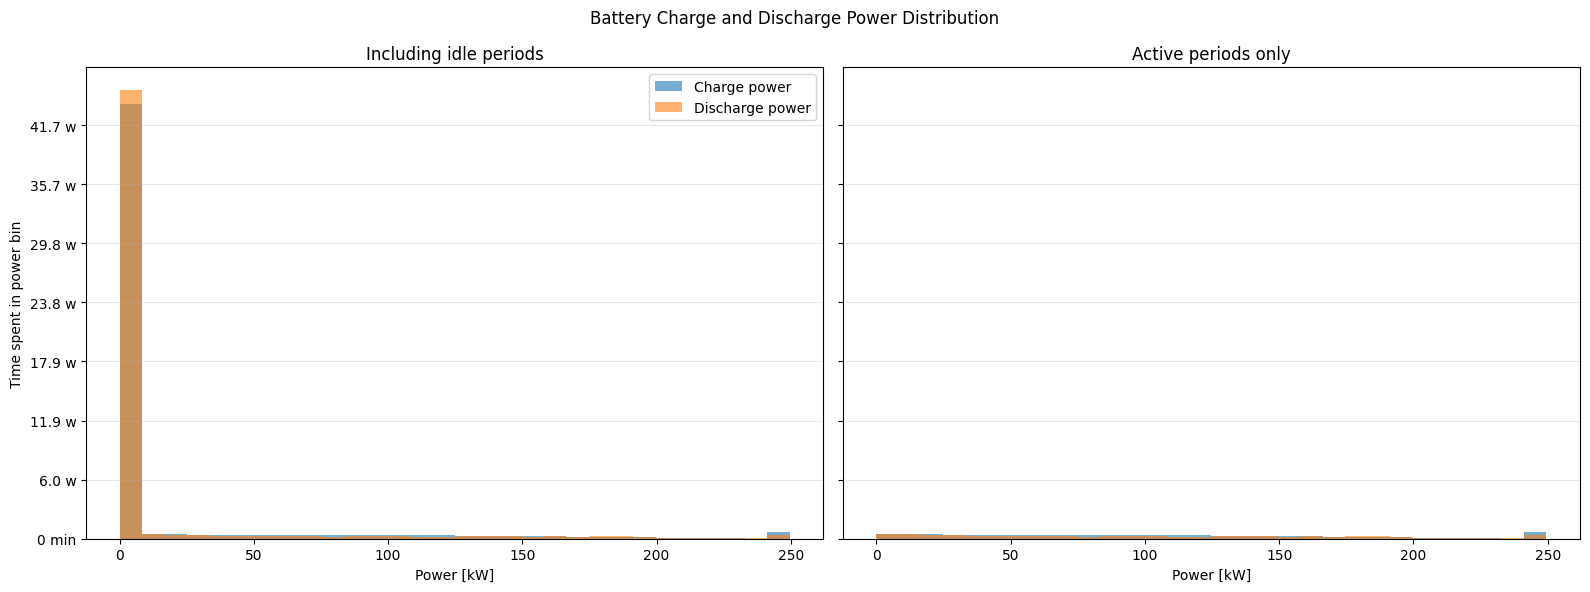

In [8]:
if {"battery_charge_power", "battery_discharge_power"}.issubset(df.columns):
    charge_power_all = df["battery_charge_power"]
    discharge_power_all = df["battery_discharge_power"]
    charge_power_active = df.loc[df["battery_charge_power"] > 1e-9, "battery_charge_power"]
    discharge_power_active = df.loc[df["battery_discharge_power"] > 1e-9, "battery_discharge_power"]

    combined_power = pd.concat([charge_power_all, discharge_power_all], ignore_index=True)
    if combined_power.empty:
        common_bins = 30
    else:
        power_min = float(combined_power.min())
        power_max = float(combined_power.max())
        if np.isclose(power_min, power_max):
            power_max = power_min + 1.0
        common_bins = np.linspace(power_min, power_max, 31)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True, sharey=True)
    plot_configs = [
        (axes[0], charge_power_all, discharge_power_all, "Including idle periods"),
        (axes[1], charge_power_active, discharge_power_active, "Active periods only"),
    ]

    for ax, charge_series, discharge_series, subtitle in plot_configs:
        if not charge_series.empty:
            ax.hist(
                charge_series,
                bins=common_bins,
                weights=np.full(len(charge_series), timestep_hours),
                alpha=0.6,
                label="Charge power",
                color="tab:blue",
            )
        if not discharge_series.empty:
            ax.hist(
                discharge_series,
                bins=common_bins,
                weights=np.full(len(discharge_series), timestep_hours),
                alpha=0.6,
                label="Discharge power",
                color="tab:orange",
            )
        ax.set_xlabel("Power [kW]")
        ax.set_title(subtitle)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(duration_tick_formatter))
        ax.grid(axis="y", alpha=0.3)

    axes[0].set_ylabel("Time spent in power bin")
    axes[0].legend()
    fig.suptitle("Battery Charge and Discharge Power Distribution")
    plt.tight_layout()
    plt.show()
else:
    display(Markdown("_Run the model again to generate charge/discharge power distributions for this section._"))

In [9]:
display(Markdown("## Battery Size Sensitivity"))
if df_battery_sensitivity.empty:
    display(Markdown("_No sensitivity file found for this run. Set `run_battery_size_sensitivity=True` in `config.py`, then run the model again. If `battery_sensitivity_sizes_kwh` is empty, default sizes around the optimized battery are generated automatically._"))
else:
    sensitivity_formatters = {
        "battery_size_kwh": format_value,
        "optimized_battery_capacity_kwh": format_value,
        "optimized_battery_power_capacity_kw": format_value,
        "objective_total_cost": format_value,
        "import_cost": format_value,
        "peak_demand_cost": format_value,
        "annualized_battery_cost": format_value,
        "annual_savings": format_value,
        "npv": format_value,
        "irr": format_value,
        "payback_years": format_value,
        "discounted_payback_years": format_value,
    }
    sensitivity_formatters = {key: value for key, value in sensitivity_formatters.items() if key in df_battery_sensitivity.columns}
    display(df_battery_sensitivity.style.format(sensitivity_formatters))

## Battery Size Sensitivity

,battery_size_kwh,optimized_battery_capacity_kwh,optimized_battery_power_capacity_kw,objective_total_cost,import_cost,peak_demand_cost,annualized_battery_cost,annual_savings,npv,irr,payback_years,discounted_payback_years,status
0,0.00,0.00,0.00,-,-,"33,490.57",0.00,0.00,0.00,-,-,-,baseline
1,124.77,124.77,-,-,-,-,-,-,-,-,-,-,infeasible
2,249.54,249.54,-,-,-,-,-,-,-,-,-,-,infeasible
3,374.31,374.31,-,-,-,-,-,-,-,-,-,-,infeasible
4,499.08,499.08,-,-,-,-,-,-,-,-,-,-,infeasible
5,623.85,623.85,311.93,"41,651.46",-,"27,501.59","14,049.87",-,-,-,-,-,optimal
6,748.62,748.62,374.31,"43,263.63",-,"26,303.80","16,859.84",-,-,-,-,-,optimal
7,998.16,998.16,499.08,"46,487.99",-,"23,908.20","22,479.79",-,-,-,-,-,optimal


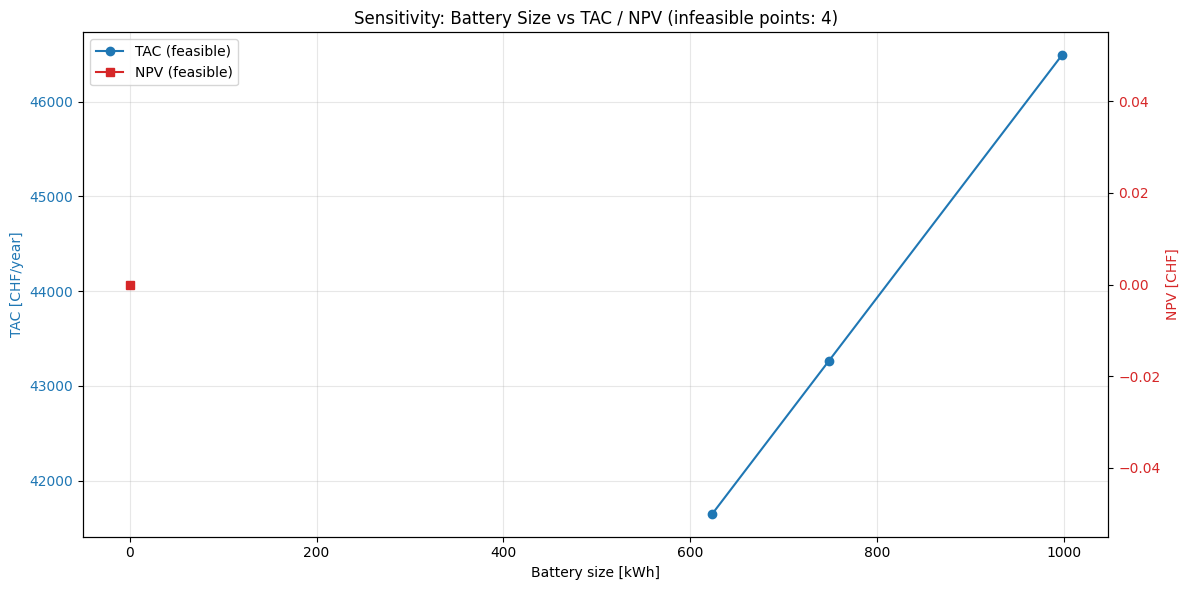

In [10]:
plot_df = df_battery_sensitivity.copy()
required_x = "battery_size_kwh"
required_any_y = ["objective_total_cost", "npv"]

if plot_df.empty:
    display(Markdown("_No sensitivity results available yet for this run._"))
elif required_x not in plot_df.columns:
    display(Markdown("_Sensitivity results found, but `battery_size_kwh` is missing. Please regenerate `battery_size_sensitivity.csv`._"))
else:
    available_y = [col for col in required_any_y if col in plot_df.columns]
    if not available_y:
        display(Markdown("_Sensitivity results found, but required KPI columns (`objective_total_cost` / `npv`) are missing. Please regenerate `battery_size_sensitivity.csv`._"))
    else:
        if "status" in plot_df.columns:
            feasible_df = plot_df[plot_df["status"].isin(["baseline", "optimal"])].copy()
            infeasible_df = plot_df[plot_df["status"] == "infeasible"].copy()
        else:
            feasible_df = plot_df.copy()
            infeasible_df = pd.DataFrame(columns=plot_df.columns)

        if feasible_df.empty and infeasible_df.empty:
            display(Markdown("_No sensitivity points available to plot._"))
        else:
            fig, ax1 = plt.subplots(figsize=(12, 6))
            ax1.set_xlabel("Battery size [kWh]")
            ax1.grid(True, alpha=0.3)

            # Feasible TAC curve
            if "objective_total_cost" in feasible_df.columns and not feasible_df.empty:
                feasible_df_sorted = feasible_df.sort_values(required_x)
                ax1.plot(
                    feasible_df_sorted[required_x],
                    feasible_df_sorted["objective_total_cost"],
                    marker="o",
                    color="tab:blue",
                    label="TAC (feasible)",
                )
                ax1.set_ylabel("TAC [CHF/year]", color="tab:blue")
                ax1.tick_params(axis="y", labelcolor="tab:blue")
            else:
                ax1.set_ylabel("TAC [CHF/year]")

            # Infeasible points (projected onto left axis if KPI available)
            if not infeasible_df.empty and "objective_total_cost" in infeasible_df.columns:
                infeasible_plot = infeasible_df.dropna(subset=["objective_total_cost"])
                if not infeasible_plot.empty:
                    ax1.scatter(
                        infeasible_plot[required_x],
                        infeasible_plot["objective_total_cost"],
                        color="crimson",
                        marker="x",
                        s=70,
                        label="Infeasible points",
                    )

            ax2 = None
            if "npv" in plot_df.columns:
                ax2 = ax1.twinx()
                if not feasible_df.empty:
                    feasible_df_sorted = feasible_df.sort_values(required_x)
                    ax2.plot(
                        feasible_df_sorted[required_x],
                        feasible_df_sorted["npv"],
                        marker="s",
                        color="tab:red",
                        label="NPV (feasible)",
                    )
                if not infeasible_df.empty:
                    infeasible_npv = infeasible_df.dropna(subset=["npv"])
                    if not infeasible_npv.empty:
                        ax2.scatter(
                            infeasible_npv[required_x],
                            infeasible_npv["npv"],
                            color="crimson",
                            marker="x",
                            s=70,
                            label="NPV infeasible points",
                        )
                ax2.set_ylabel("NPV [CHF]", color="tab:red")
                ax2.tick_params(axis="y", labelcolor="tab:red")

            # Consolidated legend
            handles, labels = ax1.get_legend_handles_labels()
            if ax2 is not None:
                h2, l2 = ax2.get_legend_handles_labels()
                handles += h2
                labels += l2
            if handles:
                ax1.legend(handles, labels, loc="best")

            infeasible_count = len(infeasible_df) if not infeasible_df.empty else 0
            plt.title(f"Sensitivity: Battery Size vs TAC / NPV (infeasible points: {infeasible_count})")
            plt.tight_layout()
            plt.show()

## Representative Dispatch Weeks

**Load definitions used in this section**  
Optimization balance per timestep:  
$grid\_flow_t + pv\_flow_t + battery\_discharge_t - battery\_charge_t = total\_demand_t$  

Derived reporting metric (actual load including battery charging):  
$actual\_load_t = grid\_flow_t + pv\_flow_t + battery\_discharge_t = total\_demand_t + battery\_charge_t$

,label,week_start
0,Winter Week,2024-12-09
1,Summer Week,2024-06-24
2,Highest-Curtailment Week,2024-07-22


Each representative week is split into three panels: (1) site net load and supply sources, (2) battery charging and discharging around a zero line, and (3) battery state of charge with the electricity price as dashed reference.

### Winter Week | Week of 2024-12-09  Peak net load: **1,732 kW**, peak actual load: **1,732 kW**, total net load: **70,567 kWh**, total actual load: **72,019 kWh**, PV used: **208 kWh**, grid import: **70,569 kWh**, battery charge/discharge: **1,452 / 1,241 kWh**, average price: **nan CHF/kWh**

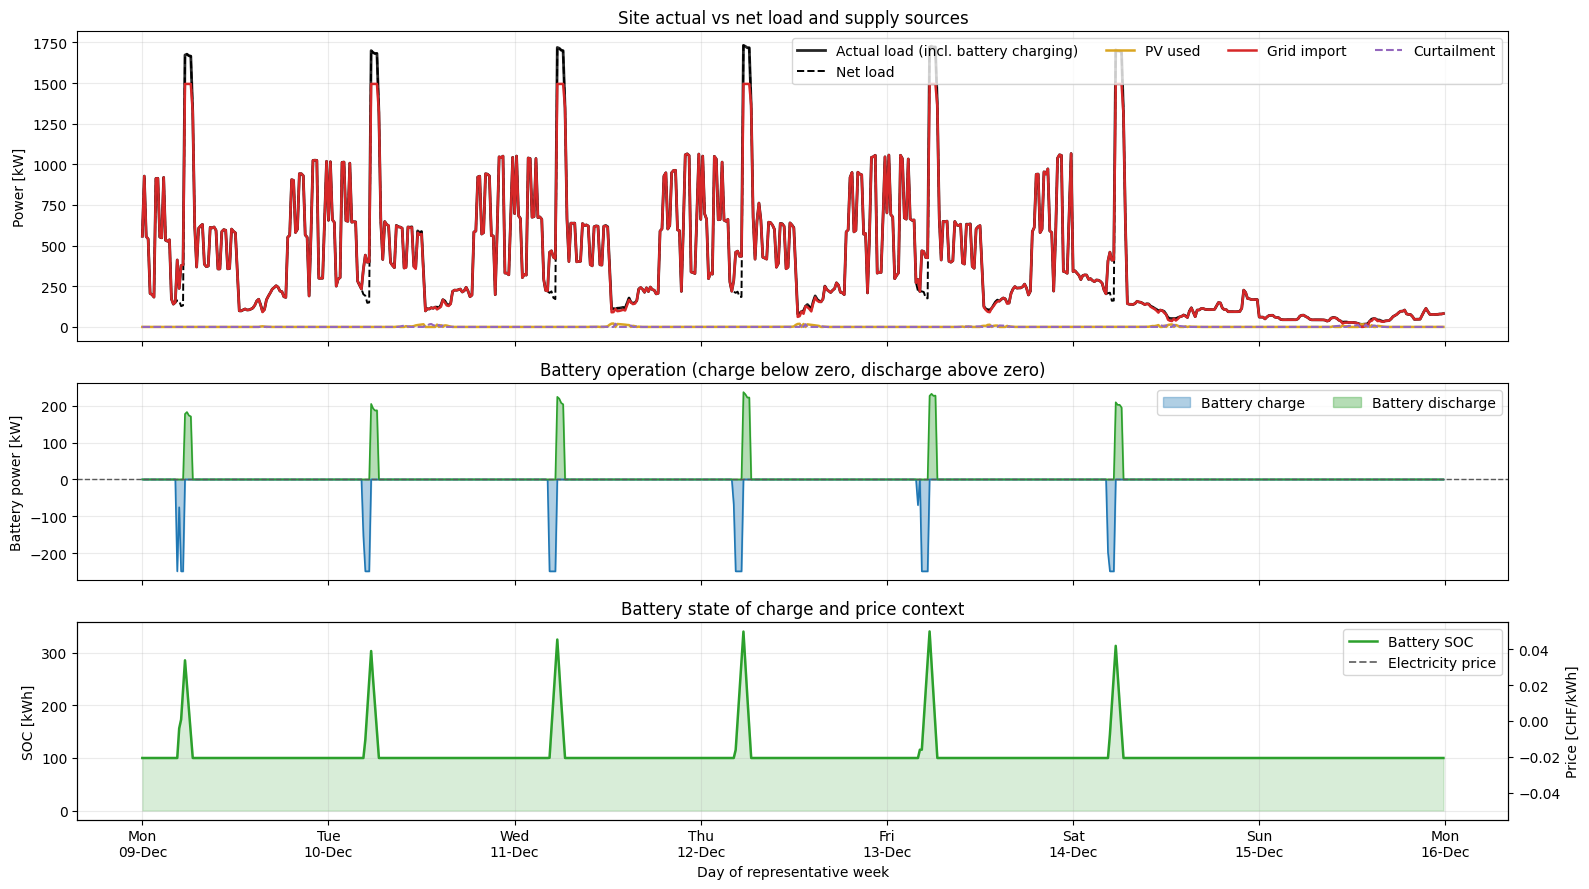

### Summer Week | Week of 2024-06-24  Peak net load: **1,028 kW**, peak actual load: **1,028 kW**, total net load: **43,029 kWh**, total actual load: **48,417 kWh**, PV used: **2,527 kWh**, grid import: **43,395 kWh**, battery charge/discharge: **2,918 / 2,495 kWh**, average price: **nan CHF/kWh**

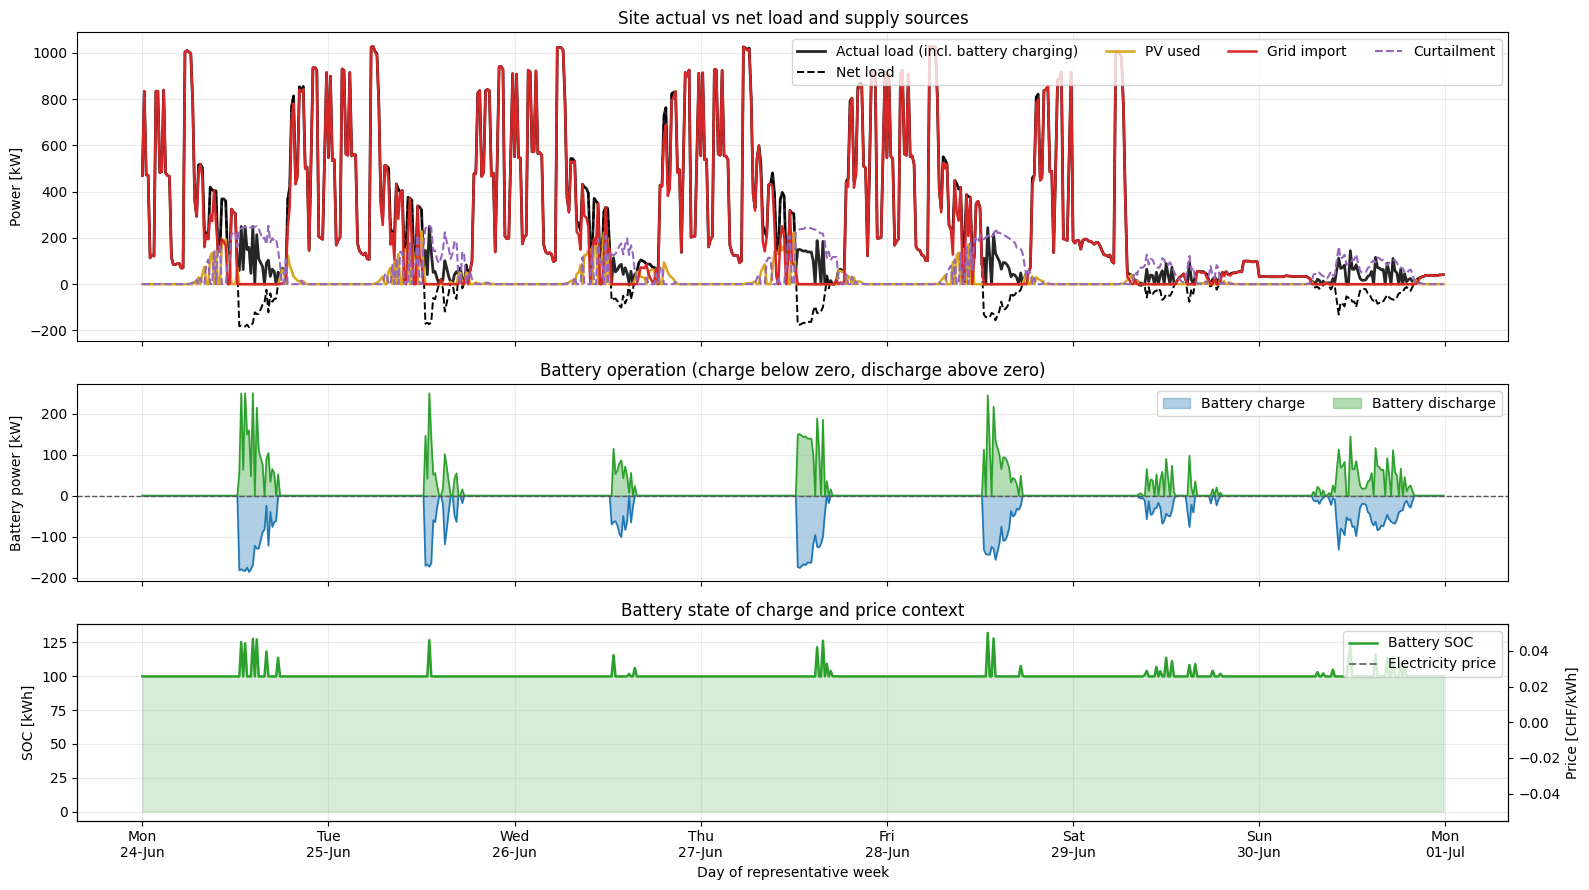

### Highest-Curtailment Week | Week of 2024-07-22  Peak net load: **1,027 kW**, peak actual load: **1,027 kW**, total net load: **39,988 kWh**, total actual load: **50,509 kWh**, PV used: **2,389 kWh**, grid import: **43,271 kWh**, battery charge/discharge: **5,672 / 4,850 kWh**, average price: **nan CHF/kWh**

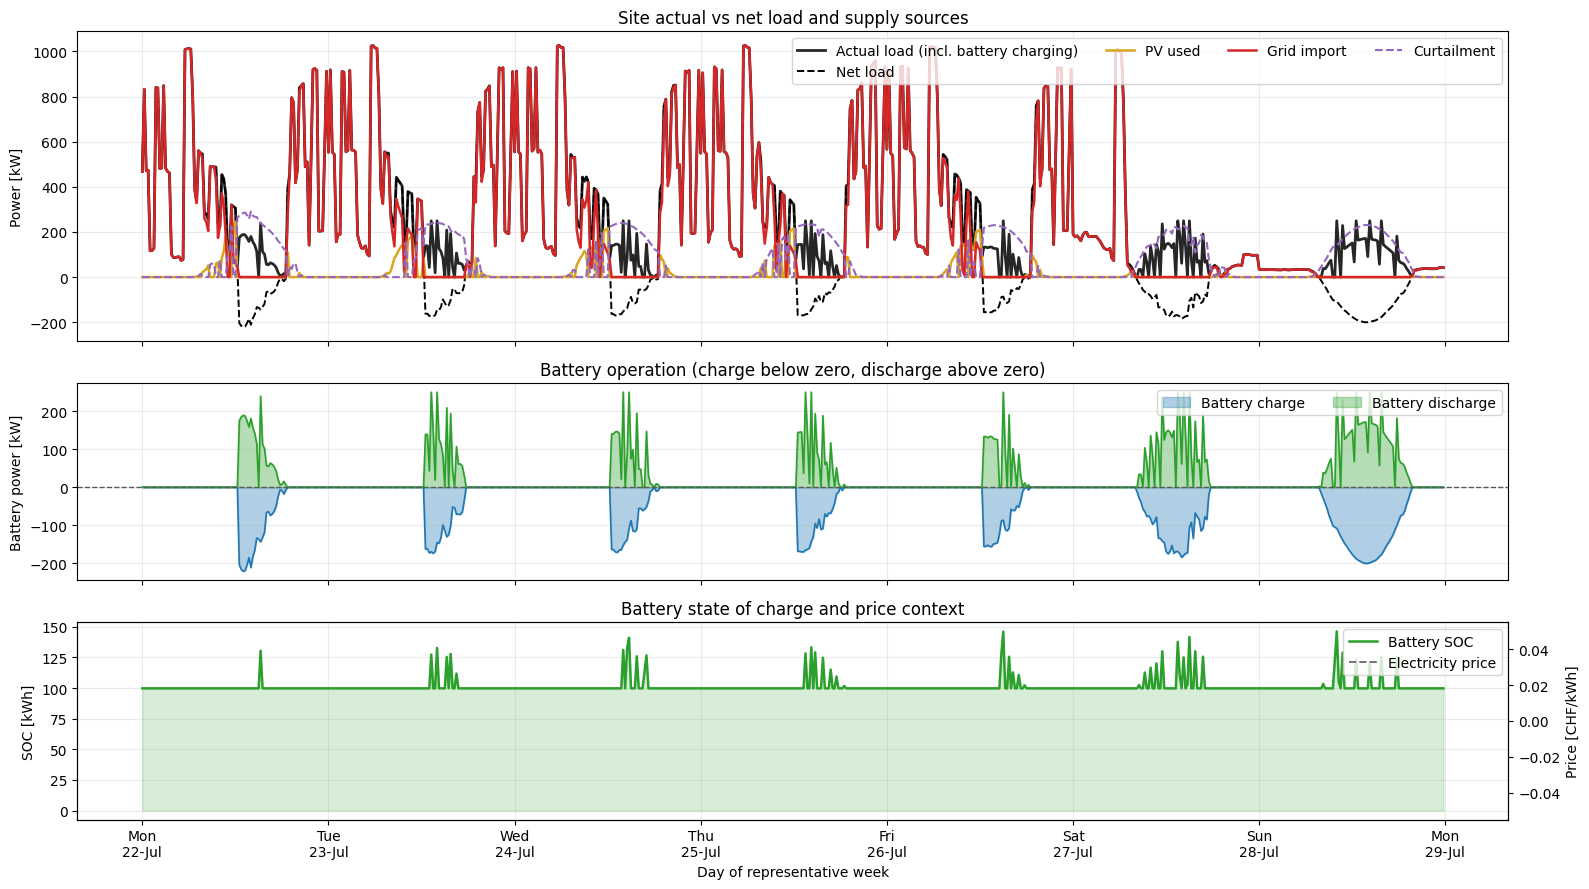

In [11]:
display(Markdown("## Representative Dispatch Weeks"))
display(Markdown(
    "**Load definitions used in this section**  \n"
    "Optimization balance per timestep:  \n"
    "$grid\\_flow_t + pv\\_flow_t + battery\\_discharge_t - battery\\_charge_t = total\\_demand_t$  \n\n"
    "Derived reporting metric (actual load including battery charging):  \n"
    "$actual\\_load_t = grid\\_flow_t + pv\\_flow_t + battery\\_discharge_t = total\\_demand_t + battery\\_charge_t$"
))
if dispatch_week_table.empty:
    display(Markdown("_No representative dispatch weeks could be identified for this run._"))
else:
    display(dispatch_week_table.style.format({"week_start": lambda v: pd.to_datetime(v).strftime('%Y-%m-%d')}))
    display(Markdown(
        "Each representative week is split into three panels: "
        "(1) site net load and supply sources, "
        "(2) battery charging and discharging around a zero line, and "
        "(3) battery state of charge with the electricity price as dashed reference."
    ))

    for week_info in selected_dispatch_weeks:
        start = pd.to_datetime(week_info["week_start"])
        end = start + pd.Timedelta(days=7)
        week_df = dispatch_df[(dispatch_df["timestamp"] >= start) & (dispatch_df["timestamp"] < end)].copy()

        if week_df.empty:
            display(Markdown(f"### {week_info['label']}"))
            display(Markdown("_No data available for this representative week._"))
            continue

        week_df["actual_load"] = (
            week_df["grid_flow"]
            + week_df["pv_flow"]
            + week_df["battery_discharge_power"]
        )

        total_net_load = week_df["total_load"].sum() * timestep_hours
        total_actual_load = week_df["actual_load"].sum() * timestep_hours
        avg_price = week_df["electricity_price"].mean()
        peak_net_load = week_df["total_load"].max()
        peak_actual_load = week_df["actual_load"].max()
        total_grid_import = week_df["grid_flow"].sum() * timestep_hours
        total_pv_used = week_df["pv_flow"].sum() * timestep_hours
        total_charge = week_df["battery_charge_power"].sum() * timestep_hours
        total_discharge = week_df["battery_discharge_power"].sum() * timestep_hours

        display(Markdown(
            f"### {week_info['label']} | Week of {start.strftime('%Y-%m-%d')}  "
            f"Peak net load: **{peak_net_load:,.0f} kW**, peak actual load: **{peak_actual_load:,.0f} kW**, "
            f"total net load: **{total_net_load:,.0f} kWh**, total actual load: **{total_actual_load:,.0f} kWh**, "
            f"PV used: **{total_pv_used:,.0f} kWh**, grid import: **{total_grid_import:,.0f} kWh**, "
            f"battery charge/discharge: **{total_charge:,.0f} / {total_discharge:,.0f} kWh**, "
            f"average price: **{avg_price:,.3f} CHF/kWh**"
        ))

        fig, axes = plt.subplots(
            3,
            1,
            figsize=(16, 9),
            sharex=True,
            gridspec_kw={"height_ratios": [2.2, 1.4, 1.4]},
        )
        ax_supply, ax_battery, ax_soc = axes

        ax_supply.plot(week_df["timestamp"], week_df["actual_load"], label="Actual load (incl. battery charging)", color="0.15", linewidth=2.0)
        ax_supply.plot(week_df["timestamp"], week_df["total_load"], label="Net load", color="black", linewidth=1.4, linestyle="--")
        ax_supply.plot(week_df["timestamp"], week_df["pv_flow"], label="PV used", color="goldenrod", linewidth=1.8)
        ax_supply.plot(week_df["timestamp"], week_df["grid_flow"], label="Grid import", color="tab:red", linewidth=1.8)
        if (week_df["spill_flow"] > 1e-9).any():
            ax_supply.plot(
                week_df["timestamp"],
                week_df["spill_flow"],
                label="Curtailment",
                color="tab:purple",
                linewidth=1.5,
                linestyle="--",
            )
        ax_supply.set_ylabel("Power [kW]")
        ax_supply.set_title("Site actual vs net load and supply sources")
        ax_supply.grid(True, alpha=0.25)
        ax_supply.legend(loc="upper right", ncol=4)

        charge_series = -week_df["battery_charge_power"].to_numpy(dtype=float)
        discharge_series = week_df["battery_discharge_power"].to_numpy(dtype=float)
        ax_battery.fill_between(week_df["timestamp"], 0, charge_series, color="tab:blue", alpha=0.35, label="Battery charge")
        ax_battery.fill_between(week_df["timestamp"], 0, discharge_series, color="tab:green", alpha=0.35, label="Battery discharge")
        ax_battery.plot(week_df["timestamp"], charge_series, color="tab:blue", linewidth=1.2)
        ax_battery.plot(week_df["timestamp"], discharge_series, color="tab:green", linewidth=1.2)
        ax_battery.axhline(0, color="0.35", linewidth=1.0, linestyle="--")
        ax_battery.set_ylabel("Battery power [kW]")
        ax_battery.set_title("Battery operation (charge below zero, discharge above zero)")
        ax_battery.grid(True, alpha=0.25)
        ax_battery.legend(loc="upper right", ncol=2)

        ax_soc.plot(week_df["timestamp"], week_df["battery_soc"], color="#2ca02c", lw=1.8, label="Battery SOC")
        ax_soc.fill_between(week_df["timestamp"], week_df["battery_soc"], alpha=0.18, color="#2ca02c")
        ax_soc.set_ylabel("SOC [kWh]")
        ax_soc.set_title("Battery state of charge and price context")
        ax_soc.grid(True, alpha=0.25)

        ax_price = ax_soc.twinx()
        ax_price.plot(
            week_df["timestamp"],
            week_df["electricity_price"],
            color="0.45",
            linewidth=1.4,
            linestyle="--",
            label="Electricity price",
        )
        ax_price.set_ylabel("Price [CHF/kWh]")

        soc_handles, soc_labels = ax_soc.get_legend_handles_labels()
        price_handles, price_labels = ax_price.get_legend_handles_labels()
        ax_soc.legend(soc_handles + price_handles, soc_labels + price_labels, loc="upper right")

        ax_soc.xaxis.set_major_locator(mdates.DayLocator())
        ax_soc.xaxis.set_major_formatter(mdates.DateFormatter("%a\n%d-%b"))
        ax_soc.set_xlabel("Day of representative week")

        plt.tight_layout()
        plt.show()

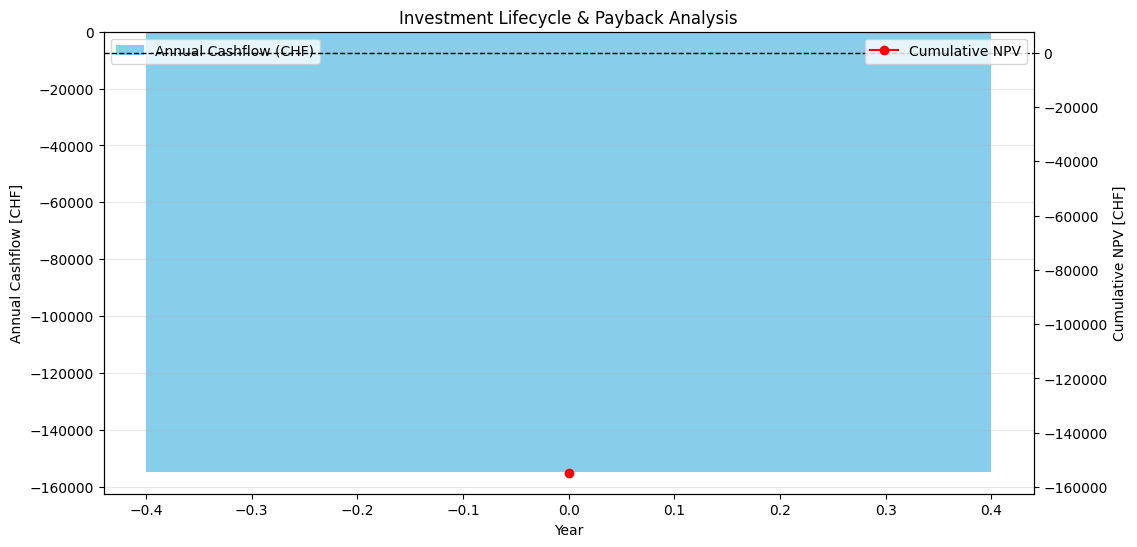

**Battery Energy Size:** 499.08 kWh

**Battery Power Rating:** 249.54 kW

**Energy CAPEX:** CHF 124,770.34

**Power CAPEX:** CHF 29,944.88

**Equivalent Full Cycles:** 264.22 cycles/year

...

**Internal Rate of Return (IRR):** nan

**Battery Replacement:** CHF 0.00 in year 15

**Curtailed Energy:** 278,249.68 kWh/year

## Detailed Output Summary

,Metric,Value
0,TAC / Objective Total Cost [CHF/year],"40,039.28"
1,OPEX [CHF/year],100.00
2,Import Cost [CHF/year],-
3,Peak Demand Cost [CHF/year],"28,699.39"
4,Fixed O&M Cost [CHF/year],100.00
5,Annualized Battery Cost [CHF/year],"11,239.89"
6,Battery Capacity [kWh],499.08
7,Battery Power Capacity [kW],249.54
8,Yearly Peak Grid Import [kW],"1,494.76"
9,Sum Monthly Peaks [kW],0.00


In [12]:
## 3. Financial Projection
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(df_fin['year'], df_fin['cashflow'], color='skyblue', label='Annual Cashflow (CHF)')
ax1.set_xlabel('Year')
ax1.set_ylabel('Annual Cashflow [CHF]')

ax2 = ax1.twinx()
ax2.plot(df_fin['year'], df_fin['discounted_cashflow'].cumsum(), color='red', marker='o', label='Cumulative NPV')
ax2.axhline(0, color='black', linewidth=1, linestyle='--')
ax2.set_ylabel('Cumulative NPV [CHF]')

plt.title("Investment Lifecycle & Payback Analysis")
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
ax1.grid(axis='y', alpha=0.3)
plt.show()

display(Markdown(f"**Battery Energy Size:** {summary.get('battery_capacity_kwh', 0):,.2f} kWh"))
display(Markdown(f"**Battery Power Rating:** {summary.get('battery_power_capacity_kw', 0):,.2f} kW"))
display(Markdown(f"**Energy CAPEX:** CHF {summary.get('energy_investment_cost', 0):,.2f}"))
display(Markdown(f"**Power CAPEX:** CHF {summary.get('power_investment_cost', 0):,.2f}"))
display(Markdown(f"**Equivalent Full Cycles:** {summary.get('equivalent_full_cycles', float('nan')):,.2f} cycles/year"))
display(Markdown(f"**Replacement Basis:** {summary.get('replacement_basis', 'N/A')}"))
display(Markdown(f"**Payback Period:** {summary.get('payback_years', 'N/A')} years"))
display(Markdown(f"**Discounted Payback Period:** {summary.get('discounted_payback_years', 'N/A')} years"))
display(Markdown(f"**Net Present Value (NPV):** CHF {summary.get('npv', 0):,.2f}"))
display(Markdown(f"**Internal Rate of Return (IRR):** {summary.get('irr', float('nan')):,.4f}"))
display(Markdown(f"**Battery Replacement:** CHF {summary.get('replacement_cost', 0):,.2f} in year {summary.get('replacement_year', 'N/A')}"))
display(Markdown(f"**Curtailed Energy:** {summary.get('curtailed_energy_kwh', 0):,.2f} kWh/year"))

display(Markdown("## Detailed Output Summary"))
display(detailed_summary_df.style.format({"Value": format_value}))